In [1]:
!pip install onnxruntime-gpu
!pip install insightface

Defaulting to user installation because normal site-packages is not writeable


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/40.1 MB ? eta -:--:--
   - -------------------------------------- 1.0/40.1 MB 12.5 MB/s eta 0:00:04
   --- ------------------------------------ 3.7/40.1 MB 12.1 MB/s eta 0:00:04
   ------ --------------------------------- 6.0/40.1 MB 11.9 MB/s eta 0:00:03
   -------- ------------------------------- 8.4/40.1 MB 11.8 MB/s eta 0:00:03
   ---------- ----------------------------- 10.7/40.1 MB 11.8 MB/s eta 0:00:03
   ------------- -------------------------- 13.4/40.1 MB 11.8 MB/s eta 0:00:03
   --------------- ------------------------ 15.7/40.1 MB 11.8 MB/s eta 0:00:03
   ------------------ --------------------- 18.1/40.1 MB 11.8 MB/s eta 0:00:02
   -------------------- ------------------- 20.7/40.1 MB 11.8 MB/s eta 0:00:02
   ----------------------- ---------------- 23.1/40.1 MB 11.9 MB/s eta 0:00:02
   ------------------------- -------------- 25.4/40.1 MB 11.8 MB/s

In [2]:
import insightface
from insightface.app import FaceAnalysis
import cv2
from ai.utils.path_utils import is_path_existed
import matplotlib.pyplot as plt
import onnxruntime as ort


In [3]:
MODE = {
    'GPU': 'CUDAExecutionProvider'
}
provider = ort.get_available_providers()
if MODE.get('GPU') not in provider:
    print("You don't have GPU")
else:
    print("You have GPU")

You have GPU


In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from insightface.app import FaceAnalysis

app = FaceAnalysis(
    name='buffalo_l',
    providers=['CUDAExecutionProvider', 'CPUExecutionProvider'],
    allowed_modules=['detection', 'recognition']
)
app.prepare(ctx_id=0, det_size=(640, 640))

img_path = is_path_existed('data/img/Screenshot (29).png')

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CUDAExecutionProvider': {'device_id': '0', 'has_user_compute_stream': '0', 'cudnn_conv1d_pad_to_nc1d': '0', 'user_compute_stream': '0', 'gpu_external_alloc': '0', 'gpu_mem_limit': '18446744073709551615', 'enable_cuda_graph': '0', 'gpu_external_free': '0', 'gpu_external_empty_cache': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'do_copy_in_default_stream': '1', 'cudnn_conv_use_max_workspace': '1', 'tunable_op_enable': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'prefer_nhwc': '0', 'use_ep_level_unified_stream': '0', 'use_tf32': '1', 'sdpa_kernel': '0', 'fuse_conv_bias': '0'}, 'CPUExecutionProvider': {}}
model ignore: C:\Users\Huy Le/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CUDAExec

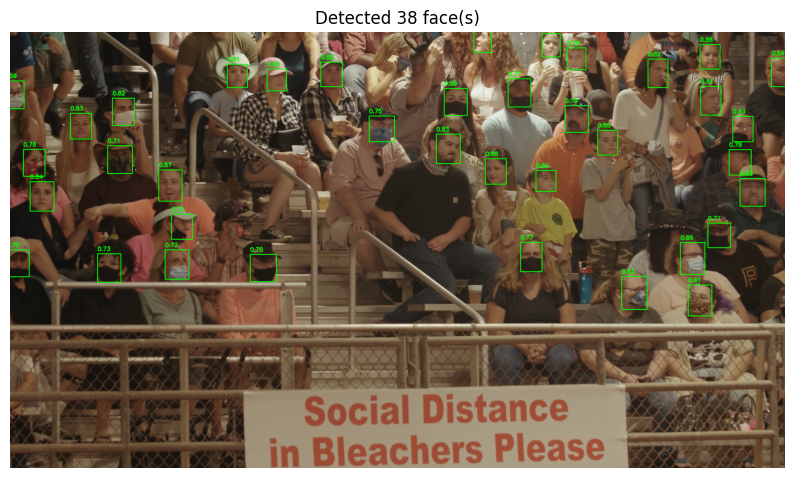

In [11]:


# Đọc ảnh
img_bgr = cv2.imread(img_path)

# Detect faces
faces = app.get(img_bgr)

# Vẽ box
img_draw = img_bgr.copy()
for face in faces:
    box = face.bbox.astype(int)
    x1, y1, x2, y2 = box
    cv2.rectangle(img_draw, (x1, y1), (x2, y2), (0, 255, 0), 2)

    # Thêm confidence score
    score = f"{face.det_score:.2f}"
    cv2.putText(img_draw, score, (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

# Convert BGR → RGB trước khi show
img_rgb = cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.axis('off')
plt.title(f"Detected {len(faces)} face(s)")
plt.show()

In [12]:
print(faces)

[{'bbox': array([1570.6229 ,  418.46982, 1639.6521 ,  502.35294], dtype=float32), 'kps': array([[1580.1898 ,  451.91486],
       [1607.109  ,  450.90088],
       [1588.7646 ,  469.91663],
       [1586.7777 ,  482.57034],
       [1608.01   ,  481.4362 ]], dtype=float32), 'det_score': np.float32(0.87846655), 'embedding': array([ 1.0505874 , -0.22273637, -1.6362023 , -0.5467184 ,  0.4849536 ,
       -0.1919442 ,  0.59056294,  1.1361457 , -0.40344533,  0.9144876 ,
        2.41498   , -1.2881461 , -1.2459317 , -1.0756003 , -0.6192784 ,
       -0.38539633, -0.59802943,  0.98608947,  0.35669202, -0.7460118 ,
       -0.16392358,  0.06159293, -0.29768187, -0.19296303, -0.27883884,
       -0.16553348, -0.11319701, -0.3518318 ,  0.8896634 , -0.28421557,
        1.605163  ,  0.87842566, -0.73769087,  0.638551  , -0.22751947,
        1.4500638 ,  1.5525981 , -0.10230536, -1.0012429 ,  0.41061166,
        0.25536853,  1.0565706 , -1.3230814 , -3.1937044 , -1.1767892 ,
       -0.27822343,  1.7996762 